In [1]:
import os
import pandas as pd
from google.cloud import bigquery

# 1. On indique à Python où se cache ta clé de sécurité JSON
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\Administrator\Downloads\Churn_project\telecom-churn-xai-069057891815.json"

# 2. On initialise le client BigQuery
client = bigquery.Client()

# 3. On écrit la requête SQL pour récupérer les données brutes
query = """
SELECT * FROM `telecom-churn-xai.raw_telecom.customer_churn_raw`
"""

# 4. On charge le résultat directement dans un DataFrame Pandas
print("Chargement des données depuis BigQuery en cours...")
df = client.query(query).to_dataframe()

# 5. On affiche les 5 premières lignes pour valider
print(f"Extraction réussie ! Volume récupéré : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
df.head()


Chargement des données depuis BigQuery en cours...


C:\WINDOWS\system32\churn_env\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Extraction réussie ! Volume récupéré : 7043 lignes, 21 colonnes.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9426-SXNHE,Female,0,False,False,2,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Bank transfer (automatic),18.75,53.15,False
1,3806-YAZOV,Female,0,False,False,3,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.80,56,False
2,3387-PLKUI,Female,0,True,True,13,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.80,251.25,False
3,8992-CEUEN,Female,0,False,False,1,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Electronic check,18.85,18.85,False
4,0620-XEFWH,Male,0,True,True,4,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.85,84.2,False


--- Répartition des clients (Chiffres exacts) ---
Churn
False    5174
True     1869
Name: count, dtype: Int64

--- Répartition en pourcentage ---
Churn
False    73.463013
True     26.536987
Name: proportion, dtype: Float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_22736\2667443618.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


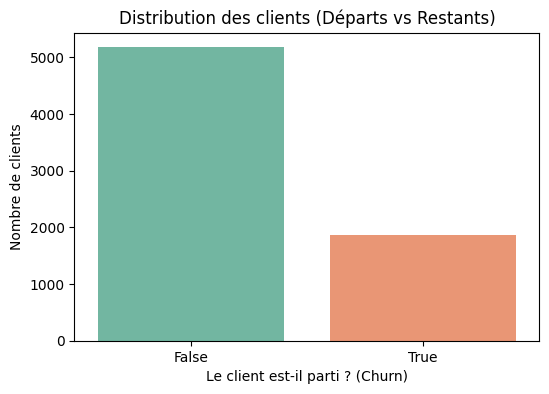

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Afficher les chiffres exacts du Churn
print("--- Répartition des clients (Chiffres exacts) ---")
print(df['Churn'].value_counts())
print("\n--- Répartition en pourcentage ---")
print(df['Churn'].value_counts(normalize=True) * 100)

# 2. Dessiner un graphique pour mieux visualiser
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution des clients (Départs vs Restants)')
plt.xlabel('Le client est-il parti ? (Churn)')
plt.ylabel('Nombre de clients')
plt.show()

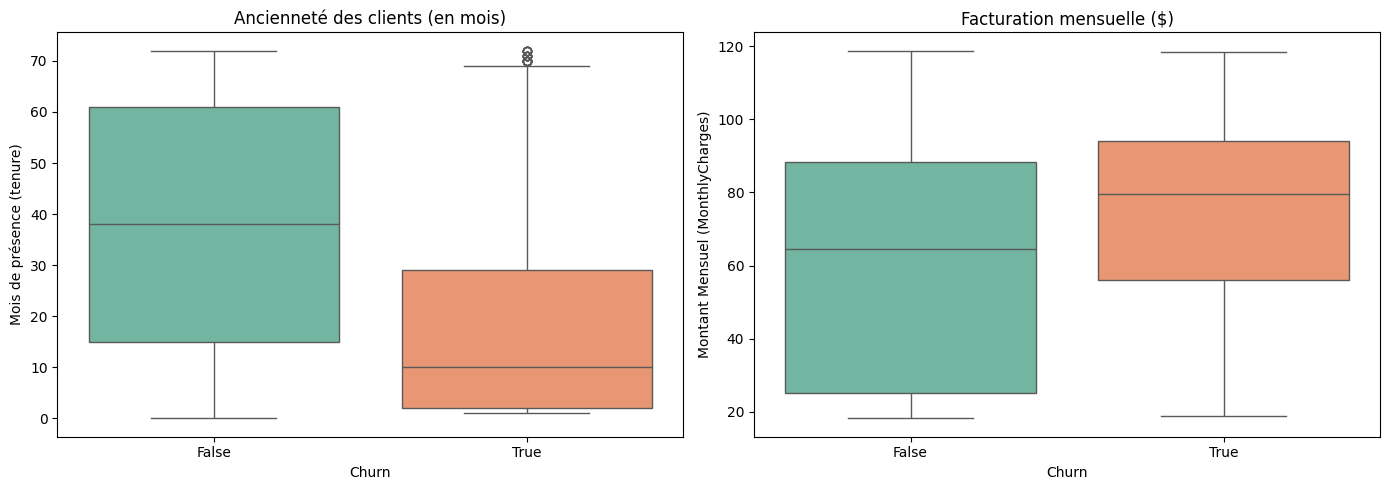

In [3]:
# Crée une zone de graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution de l'ancienneté (tenure) selon le Churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2', hue='Churn', legend=False)
axes[0].set_title("Ancienneté des clients (en mois)")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Mois de présence (tenure)")

# Graphique 2 : Distribution des charges mensuelles selon le Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2', hue='Churn', legend=False)
axes[1].set_title("Facturation mensuelle ($)")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Montant Mensuel (MonthlyCharges)")

plt.tight_layout()
plt.show()

In [4]:
import numpy as np

# 1. Copie de sauvegarde
df_ml = df.copy()

# 2. Nettoyage de la colonne TotalCharges (conversion des espaces vides en NaN puis en zéros)
df_ml['TotalCharges'] = df_ml['TotalCharges'].replace(" ", np.nan)
df_ml['TotalCharges'] = df_ml['TotalCharges'].astype(float).fillna(0.0)

# 3. Encodage de la variable cible (Churn) et des variables binaires en 0 et 1
df_ml['Churn'] = df_ml['Churn'].map({True: 1, False: 0})
df_ml['gender'] = df_ml['gender'].map({'Female': 1, 'Male': 0})
df_ml['Partner'] = df_ml['Partner'].map({True: 1, False: 0})
df_ml['Dependents'] = df_ml['Dependents'].map({True: 1, False: 0})
df_ml['PhoneService'] = df_ml['PhoneService'].map({True: 1, False: 0})
df_ml['PaperlessBilling'] = df_ml['PaperlessBilling'].map({True: 1, False: 0})

# 4. Encodage des autres variables textuelles (One-Hot Encoding)
variables_a_encoder = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
                        'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                        'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df_ml = pd.get_dummies(df_ml, columns=variables_a_encoder, drop_first=True, dtype=int)

# 5. On supprime l'ID client qui ne sert pas pour le modèle mathématique
df_ml = df_ml.drop(columns=['customerID'])

print("--- Matrice de Features Prête pour le Machine Learning ! ---")
print(f"Nouvelles dimensions : {df_ml.shape[0]} lignes et {df_ml.shape[1]} colonnes numériques.")
df_ml.head()

--- Matrice de Features Prête pour le Machine Learning ! ---
Nouvelles dimensions : 7043 lignes et 31 colonnes numériques.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,2,1,0,18.75,53.15,0,...,0,1,0,1,0,0,0,0,0,0
1,1,0,0,0,3,1,0,18.80,56.00,0,...,0,1,0,1,0,0,0,0,0,1
2,1,0,1,1,13,1,0,18.80,251.25,0,...,0,1,0,1,0,0,0,0,0,1
3,1,0,0,0,1,1,0,18.85,18.85,0,...,0,1,0,1,0,0,0,0,1,0
4,0,0,1,1,4,1,0,18.85,84.20,0,...,0,1,0,1,0,0,0,0,0,1


In [6]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.8 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.1 MB 1.2 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.1 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.1 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.1 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.1 MB 1.3 MB/s eta 0:00:05
   -------------- ------------------------- 2.9/8.1 MB 1.3 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.1 MB 1.3 MB/s eta 0:00:04
   ---------------- -------------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. On sépare la variable à prédire (y) du reste des données (X)
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

# 2. On découpe en 80% Entraînement et 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Données d'entraînement : {X_train.shape[0]} clients")
print(f"Données de test : {X_test.shape[0]} clients\n")

# 3. On crée et on entraîne notre modèle Random Forest
print("Entraînement de l'intelligence artificielle en cours...")
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model_rf.fit(X_train, y_train)
print("Modèle entraîné avec succès !\n")

# 4. On demande au modèle de prédire sur les clients de test qu'il n'a jamais vus
y_pred = model_rf.predict(X_test)

# 5. On affiche le rapport de performance
print("--- PERFORMANCES DU MODÈLE ---")
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

Données d'entraînement : 5634 clients
Données de test : 1409 clients

Entraînement de l'intelligence artificielle en cours...
Modèle entraîné avec succès !

--- PERFORMANCES DU MODÈLE ---
Précision globale (Accuracy) : 80.27%

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



C:\Users\Administrator\AppData\Local\Temp\ipykernel_22736\1083242439.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df.head(10), x='Importance', y='Variable', palette='viridis')


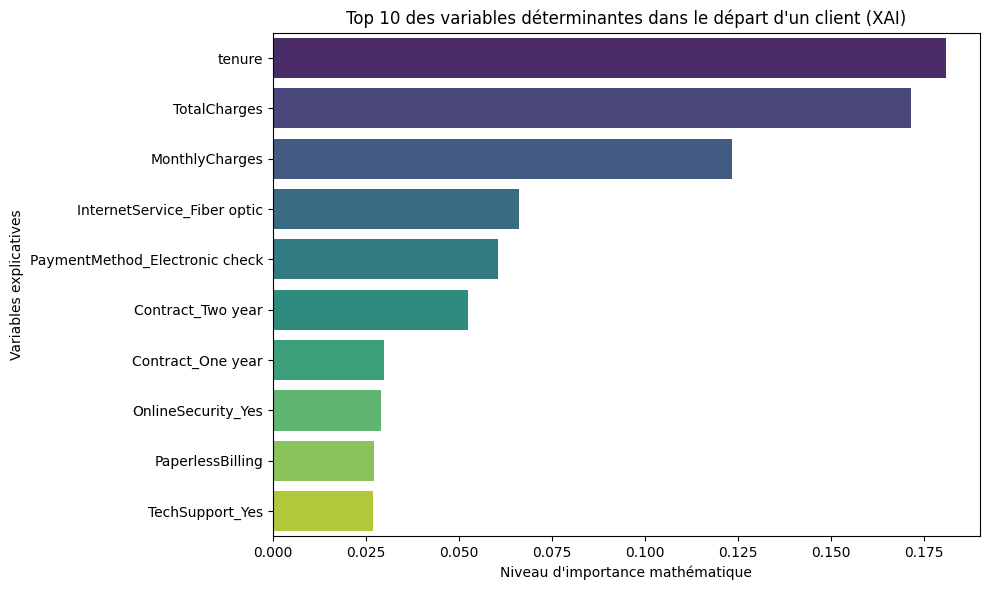

In [8]:
import numpy as np

# 1. Extraire l'importance des variables calculée par le Random Forest
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 2. Organiser ça dans un joli tableau Pandas
importances_df = pd.DataFrame({
    'Variable': X.columns[indices],
    'Importance': importances[indices]
})

# 3. Tracer le graphique des 10 variables les plus cruciales
plt.figure(figsize=(10, 6))
sns.barplot(data=importances_df.head(10), x='Importance', y='Variable', palette='viridis')
plt.title("Top 10 des variables déterminantes dans le départ d'un client (XAI)")
plt.xlabel("Niveau d'importance mathématique")
plt.ylabel("Variables explicatives")
plt.tight_layout()
plt.show()